# 🧠 Training Machine Learning Models – How to Optimise Performance

---

**Presentation Duration:** ~45 minutes  
**Format:** Interactive Jupyter Notebook  
**Author:** Sam Yeend & Meghana Reddy Vemula

---


## 📋 Section 0 — Pre-Requisites & Introduction

### Pre-Requisites
- Prior exposure to machine learning concepts
- Prior experience with Python

### What This Talk Covers
We're **not** teaching ML from scratch — we're teaching you how to **make ML models perform better** through:
1. **Feature Selection** — give the model better inputs
2. **Hyperparameter Optimisation** — tune the model's configuration
3. **Auto Model Selection** — try different model architectures entirely

### What We'll Build
A complete, runnable Jupyter Notebook — from synthetic data generation through to an optimised, automatically selected model.

---


### 📦 Install Required Packages
Run the cell below to install all required packages (skip if already installed).


In [ ]:
# 📦 Install browser-compatible packages (JupyterLite / Pyodide)
# numpy · pandas · scipy · scikit-learn · matplotlib auto-load on import.
# seaborn and optuna are fetched here. Safe to re-run; works in normal Jupyter too.
%pip install -q seaborn optuna

In [1]:
# ── Core Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

# ── Scikit-learn ──────────────────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, log_loss
)
from sklearn.decomposition import PCA
from scipy.stats import randint

# ── Optuna ────────────────────────────────────────────────────
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Pycaret ────────────────────────────────────────────────────
# from pycaret.classification import ClassificationExperiment

# # Suppress PyCaret's logs.log file
# os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

# # Suppress CatBoost's training info folder
# os.environ["CATBOOST_LOGGING_LEVEL"] = "Silent"

# os.environ["CATBOOST_PARAMS"] = '{"logging_level": "Silent", "allow_writing_files": false}'

# ── Settings ──────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


---

## 🤖 Section 1 — What is a Machine Learning Model?

### Definition
**Machine Learning** is a subset of Artificial Intelligence where algorithms **learn patterns from data** and use those patterns to make predictions or decisions — **without being explicitly programmed with rules**.

### ML vs Traditional Programming

| | Traditional Programming | Machine Learning |
|---|---|---|
| **Approach** | Developer writes explicit rules | Model learns rules from data |
| **Input** | Rules + Data → Output | Data + Output → Rules |
| **Adaptability** | Static — only changes when code is rewritten | Dynamic — adapts as new data arrives |
| **Best for** | Simple, well-defined problems | Complex, data-rich problems |

### The Core Idea
> *"An ML model takes in data, finds patterns, and uses those patterns to make predictions on new, unseen data."*

### The ML Workflow

```
📊 Data  →  🔧 Features  →  🏋️ Model Training  →  📏 Evaluation  →  🔮 Prediction
```

We start with raw data, transform it into meaningful features, train a model to learn from those features, evaluate how well it generalises, and then use it to predict on new data.

---


## 📊 Section 2 — The Data

We'll generate **synthetic classification data** that we'll use as a running example throughout this entire presentation.

### 🎯 The Problem We're Solving

Imagine we run a fleet of network devices (or any system you like) and we want a model that can answer one question:

> *"Given everything we know about this device right now, is it faulty or is it healthy?"*

This is a classic **binary classification** problem:

- **Target = `1`** → **Fault** (something is wrong / a failure occurred)
- **Target = `0`** → **Not fault** (the device is operating normally)

The **features** are our **input variables** — the 20 measurements/signals we collect about each device (CPU load, error counts, temperature, latency, etc.). The model's job is to learn the patterns in those features that distinguish a faulty device from a healthy one.

### Data Design
- **1,000 samples** (rows) — each row is one device snapshot
- **20 features** total (the variables we'll use to predict fault vs. not-fault):
  - 10 **informative** features (genuinely useful for predicting faults — e.g. real fault signals)
  - 5 **redundant** features (linear combinations of informative ones — partially useful)
  - 5 **useless/noisy** features (random noise — no predictive power, like a sensor that's broken)
- **2 classes** (binary classification):
  - `0` = **not fault** (healthy)
  - `1` = **fault** (failure)
- Target column: `target` (`0` or `1`)

---


In [2]:
# ── Generate Synthetic Data ────────────────────────────────────
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,       # 10 genuinely useful features
    n_redundant=5,           # 5 linear combinations of informative features
    n_clusters_per_class=2,
    random_state=RANDOM_STATE
)

# Create a clean DataFrame
feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}")
print(f"\n{'='*60}")
print("First 10 rows of the dataset:")
print("="*60)
df.head(10)

Dataset shape: (1000, 21)

Class distribution:
target
1    503
0    497
Name: count, dtype: int64

First 10 rows of the dataset:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,1.470848,-0.360450,-0.591602,-0.728228,0.941690,1.065964,0.017832,-0.596184,1.840712,-1.497093,...,-0.603968,2.899256,0.037567,-1.249523,0.257963,0.416628,1.408208,-1.838041,-0.833142,1
1,4.513369,-2.227103,-1.140747,2.018263,-2.238358,-0.497370,0.714550,0.938883,-2.395169,0.159837,...,1.461499,3.954171,0.309054,0.538184,-7.157865,-4.532216,-0.081800,-9.325362,0.574386,1
2,-2.355643,2.218601,-1.603269,0.873394,0.401483,0.717264,-0.859399,-1.042190,-2.175965,0.980231,...,0.544434,-2.466258,-0.470256,0.073018,-2.203531,-2.299263,-1.742761,-0.271579,-0.359285,0
3,-1.596198,-0.857427,1.772434,-0.639361,1.419409,-0.438525,0.281949,2.345145,1.006230,0.389135,...,-1.025051,-2.422975,1.579807,-0.300713,4.267120,2.893775,1.236697,6.034785,-0.045711,0
4,2.840049,-2.489600,-0.844902,-1.594362,-4.688517,0.459637,0.913607,-1.143505,1.263937,-2.040928,...,4.176424,1.341742,0.133565,1.743819,1.531188,2.269808,0.053489,-3.151109,1.603702,0
5,1.580587,0.435768,0.184096,-2.407114,-3.635329,-0.592799,-0.023394,-2.167272,2.016957,-1.705669,...,-3.268830,2.773557,-2.382762,2.712426,5.901931,0.091224,-0.116741,-1.130036,-0.480170,0
6,2.019606,-3.926191,-3.545442,-0.393030,1.111432,-0.094273,0.181461,-0.101641,-4.912845,-1.810807,...,-0.315110,-9.946681,-1.313528,1.165445,8.872096,6.390253,-3.850770,-1.744600,-0.144000,0
7,0.936169,0.401295,1.709292,1.050826,-1.644753,1.530186,-0.642127,-0.067696,-0.685402,0.043670,...,-0.778601,1.741081,-2.026578,1.823222,-0.950423,-0.342347,-0.448039,-0.526576,-0.314601,0
8,1.323345,1.016132,1.806313,1.203681,-0.220407,0.609813,0.377712,-1.923051,1.461840,-2.775015,...,-1.907878,4.567854,1.753375,2.755435,3.268577,2.979580,1.849095,1.312568,-1.318092,0
9,-0.096290,-0.328778,0.374652,0.682909,-0.002984,0.708266,0.775675,-0.635783,-0.394945,0.373931,...,1.475155,-0.292435,1.889282,-0.431857,-3.692869,-1.213137,-1.805413,-2.938012,0.783466,0


✅ Separable feature:     feature_14
❌ Non-separable feature: feature_19


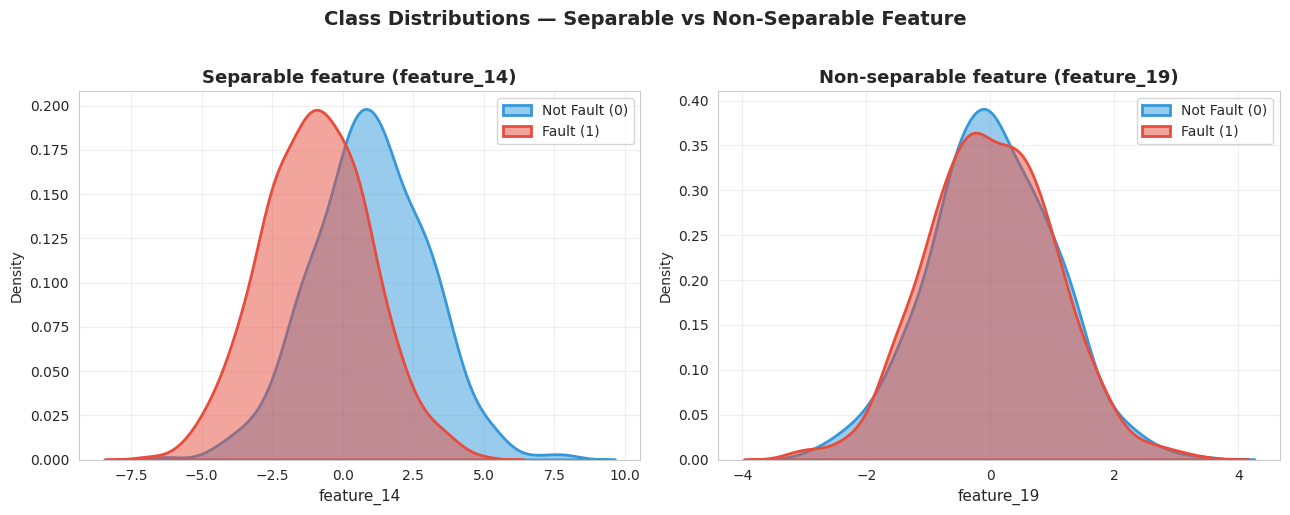


👉 Left plot: the blue and red curves are clearly shifted apart
   → this feature carries real signal about fault vs. not-fault.
👉 Right plot: the blue and red curves overlap almost perfectly
   → this feature is essentially noise for our prediction task.

This is exactly what we'll exploit in Section 5 (Feature Selection):
keep features that look like the left plot, drop features that look like the right.


In [3]:
# ── KDE Separability Plot — Separable vs Non-Separable Feature ─
# Hardcoded features for consistent slides
best_feature  = "feature_14"   # separable
worst_feature = "feature_19"   # non-separable

print(f"✅ Separable feature:     {best_feature}")
print(f"❌ Non-separable feature: {worst_feature}")

# ── Plot the two KDEs side by side ─────────────────────────────
class_colors = {0: "#3498db", 1: "#e74c3c"}
class_labels = {0: "Not Fault (0)", 1: "Fault (1)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feature, title in [
    (axes[0], best_feature,  f"Separable feature ({best_feature})"),
    (axes[1], worst_feature, f"Non-separable feature ({worst_feature})"),
]:
    for cls in [0, 1]:
        sns.kdeplot(
            df.loc[df["target"] == cls, feature],
            ax=ax,
            fill=True,
            alpha=0.5,
            color=class_colors[cls],
            label=class_labels[cls],
            linewidth=2,
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Class Distributions — Separable vs Non-Separable Feature",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n👉 Left plot: the blue and red curves are clearly shifted apart")
print("   → this feature carries real signal about fault vs. not-fault.")
print("👉 Right plot: the blue and red curves overlap almost perfectly")
print("   → this feature is essentially noise for our prediction task.")
print("\nThis is exactly what we'll exploit in Section 5 (Feature Selection):")
print("keep features that look like the left plot, drop features that look like the right.")

### Understanding the Structure

| Component | Description | Example |
|---|---|---|
| **Features (X)** | The input variables the model learns from | `feature_0`, `feature_1`, ..., `feature_19` |
| **Target / Label (y)** | The thing we're trying to predict | `target` (0 or 1) |

---

---

## 🏋️ Section 3 — How is the Model Trained?

This section walks through the **full training pipeline** step by step.

---

### 3a. Splitting the Data

**Why do we split?**

If we evaluate the model on the same data it was trained on, we're measuring **memorisation**, not **generalisation**. The model might look great on training data but fail completely on new, unseen data — a problem called **overfitting**.

A separate **test set** simulates real-world deployment: data the model has *never* seen during training.

```
┌─────────────────────────────────────────────────┐
│                  Full Dataset                    │
│                  (1,000 rows)                    │
├────────────────────────┬────────────────────────┤
│    🏋️ Train Set (80%)  │    🧪 Test Set (20%)    │
│    800 rows            │    200 rows             │
│    Features + Labels   │    Features + Labels    │
│    (model sees this)   │    (held back)          │
└────────────────────────┴────────────────────────┘
```

---


In [4]:
# ── Split the Data ─────────────────────────────────────────────
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:      {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set:  800 samples, 20 features
Test set:      200 samples, 20 features

Train class distribution:
target
1    402
0    398
Name: count, dtype: int64

Test class distribution:
target
1    101
0     99
Name: count, dtype: int64


### Preprocessing — Standardisation

Many ML models are sensitive to the **scale** of input features. A feature ranging from 0–1,000 can dominate a feature ranging from 0–1.

**Standardisation** transforms each feature to have **mean = 0** and **standard deviation = 1**.

```
z = (x - mean) / std
```

> ⚠️ **Important:** We fit the scaler on the **training data only**, then apply the same transformation to the test data. This prevents **data leakage** — information from the test set contaminating the training process.

---

In [5]:
# ── Standardise the Features ───────────────────────────────────
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

print("Before scaling (first row of X_train):")
print(X_train.iloc[0].values[:5].round(3))
print("\nAfter scaling (first row of X_train_scaled):")
print(X_train_scaled.iloc[0].values[:5].round(3))
print("\n✅ Scaling complete — mean ≈ 0, std ≈ 1 on training data")

Before scaling (first row of X_train):
[ 1.237  5.57  -1.275 -0.59   1.319]

After scaling (first row of X_train_scaled):
[ 0.575  2.655 -0.406 -0.279  0.267]

✅ Scaling complete — mean ≈ 0, std ≈ 1 on training data


### 3b. The Model — Random Forest Classifier

We'll use a **Random Forest** as our model for this entire presentation. Here's why:
- ✅ Intuitive to explain (ensemble of decision trees)
- ✅ Has clear hyperparameters to tune later
- ✅ Provides built-in **feature importances** (connects to Section 5)
- ✅ A real workhorse in production ML

---

### Building Block: The Decision Tree

A **decision tree** is a flowchart-like model that splits the data into smaller and smaller groups by asking a series of yes/no questions on the features.

```
                ┌────────────────────┐
                │ Is feature_A > 5 ? │
                └─────────┬──────────┘
                  Yes     │     No
            ┌─────────────┴─────────────┐
            ▼                           ▼
   ┌────────────────────┐      ┌────────────────────┐
   │ Is feature_B > 0 ? │      │      Class 0       │
   └─────────┬──────────┘      └────────────────────┘
       Yes   │   No
       ┌─────┴─────┐
       ▼           ▼
   ┌───────┐   ┌───────┐
   │Class 1│   │Class 0│
   └───────┘   └───────┘
```

**How a single tree learns:**
1. At each node, the algorithm searches across features and thresholds to find the split that best **separates the classes** (using a criterion like *Gini impurity* or *entropy*).
2. It keeps splitting recursively until a stopping rule is hit (e.g. `max_depth`, `min_samples_leaf`, or pure leaves).
3. To predict, a new row is "dropped" down the tree and lands in a leaf — the leaf's majority class is the prediction.

**The catch:** a single deep decision tree tends to **overfit** — it memorises noise in the training data and generalises poorly. Random Forest fixes this by combining many *de-correlated* trees.

---

### How Random Forest Works (High Level)

```
                    ┌──────────┐
                    │ Full     │
                    │ Dataset  │
                    └─────┬────┘
            ┌─────────┬───┴───┬─────────┐
            ▼         ▼       ▼         ▼
       ┌────────┐ ┌────────┐ ┌────────┐ ┌────────┐
       │ Tree 1 │ │ Tree 2 │ │ Tree 3 │ │ Tree N │   ← Each tree sees a
       │(random │ │(random │ │(random │ │(random │     random subset of
       │ subset)│ │ subset)│ │ subset)│ │ subset)│     rows & features
       └───┬────┘ └───┬────┘ └───┬────┘ └───┬────┘
           │          │          │          │
           ▼          ▼          ▼          ▼
        Class 1    Class 0    Class 1    Class 1

                    ┌──────────┐
                    │ MAJORITY │
                    │   VOTE   │ → Final Prediction: Class 1
                    └──────────┘
```

1. Build **many decision trees**, each trained on a random subset of the rows and features.
2. Each tree independently **votes** on the prediction.
3. The final prediction is the **majority vote** across all trees.

This is called **ensemble learning** — *"many weak learners combine to form a strong learner"*.

---

### The Two Sources of Randomness 🎲

Look back at **Tree 1, Tree 2, Tree 3, ... Tree N** in the diagram above. Each one is built on a **different slice of the data** — and that slice differs in two ways:

#### 1. Each tree sees different **rows** 🧾

Before training, the forest hands each tree its own randomly-sampled set of rows from the training data (sampled *with replacement*, so a row can appear more than once in a tree's data).

Say our dataset has **1,000 rows**:

- **Tree 1** might be trained on rows `[3, 17, 17, 42, 88, 201, ...]`
- **Tree 2** might be trained on rows `[5, 5, 19, 60, 88, 154, ...]`
- **Tree 3** might be trained on rows `[1, 22, 33, 44, 77, 99, ...]`

Each tree sees roughly **63%** of the unique rows; the rest are unseen for that tree (those leftover rows are called **Out-Of-Bag** samples and can be used as a free validation set).

#### 2. Each tree (at every split) sees different **columns** 🧮

When a tree is deciding *how* to split a node, it doesn't look at all 20 features — it only considers a **random handful**.

Say our dataset has **20 features** (`feature_1` … `feature_20`). With the default `max_features="sqrt"`, only **√20 ≈ 4 features** are considered at each split:

- **Tree 1's** first split might choose from `[feature_2, feature_7, feature_11, feature_19]`
- **Tree 2's** first split might choose from `[feature_1, feature_5, feature_14, feature_20]`
- **Tree 3's** first split might choose from `[feature_3, feature_8, feature_12, feature_17]`

And it picks a **new random handful at every single split**, not just once per tree.

#### Why both matter

- **Different rows** → each tree learns from a slightly different "world", so they don't all overfit to the same noise.
- **Different columns** → trees can't all latch onto the same dominant feature, so the votes are genuinely independent.

Together, these two tricks turn a bunch of overfitting decision trees into a robust ensemble where the **majority vote is much smarter than any individual tree**.

In [6]:
# ── Train a Random Forest with DEFAULT hyperparameters ─────────
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
rf_baseline.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_proba_baseline = rf_baseline.predict_proba(X_test_scaled)

# Evaluate
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_logloss = log_loss(y_test, y_proba_baseline)

print("=" * 60)
print("BASELINE MODEL — Random Forest (Default Hyperparameters)")
print("=" * 60)
print(f"\nAccuracy:  {baseline_accuracy:.4f}")
print(f"Log Loss:  {baseline_logloss:.4f}")

BASELINE MODEL — Random Forest (Default Hyperparameters)

Accuracy:  0.9100
Log Loss:  0.2899


---

### 3c. The Loss Function

**What is a loss function?**

A loss function is a mathematical measure of **how wrong** the model's predictions are. It quantifies the gap between what the model predicted and what the true answer was.

For **classification**, a common loss function is **Log Loss (Cross-Entropy)**:

$$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{p}_i) + (1 - y_i) \cdot \log(1 - \hat{p}_i) \right]$$

Where:
- $y_i$ = true label (0 or 1)
- $\hat{p}_i$ = predicted probability of class 1
- $N$ = number of samples

**Key insight:** Log Loss **penalises confident wrong predictions more heavily**. If the model says "I'm 99% sure this is Class 1" and it's actually Class 0, the loss is massive.

> 🎯 **The big takeaway:** *Training a model = finding the settings that minimise the loss function.* Everything we do from here — feature selection, hyperparameter tuning — is about **reducing this loss**.

---


In [7]:
# ── Compute Log Loss ───────────────────────────────────────────
print(f"Baseline Log Loss: {baseline_logloss:.4f}")
print()
print("Interpretation:")
print("  • Log Loss = 0    → Perfect predictions")
print("  • Log Loss ↑      → Worse predictions")
print(f"  • Our model:       {baseline_logloss:.4f}")
print()
print("Our goal for the rest of this presentation:")
print("  → Reduce this loss (and increase accuracy) through")
print("    feature selection, hyperparameter tuning, and model selection.")

Baseline Log Loss: 0.2899

Interpretation:
  • Log Loss = 0    → Perfect predictions
  • Log Loss ↑      → Worse predictions
  • Our model:       0.2899

Our goal for the rest of this presentation:
  → Reduce this loss (and increase accuracy) through
    feature selection, hyperparameter tuning, and model selection.


---

### 3d. Data Flow — How Training Actually Works

```
┌──────────────┐      ┌──────────────┐       ┌──────────────┐
│   INPUT      │      │    MODEL     │       │   OUTPUT     │
│              │      │              │       │              │
│  Features    │────▶│ Random Forest│──────▶│  Prediction  │
│  (X_train)   │      │  (learns     │       │  (ŷ)         │
│              │      │   patterns)  │       │              │
└──────────────┘      └──────────────┘       └──────┬───────┘
                                                    │
                                                    ▼
                                             ┌──────────────┐
┌──────────────┐      ┌──────────────┐       │   COMPARE    │
│   UPDATE     │      │    LOSS      │       │              │
│              │◀─── │              │◀──────│  ŷ vs y      │
│  Adjust      │      │  Log Loss    │       │  (pred vs    │
│  internal    │      │  (how wrong?)│       │   true label)│
│  parameters  │      │              │       │              │
└──────────────┘      └──────────────┘       └──────────────┘
    
```

**The training loop:**
1. Training data (features) is fed into the model
2. The model makes predictions
3. Predictions are compared against the true labels
4. The loss function measures how wrong the model is
5. The model adjusts its internal parameters to reduce the loss
6. Repeat until the model converges

> 📝 **Note for tree-based models:** Random Forests don't use gradient-based updates like neural networks. Instead, they learn by finding the best feature splits across the entire dataset to maximise information gain. The diagram above is a conceptual simplification.

---


---

## 🚀 Section 4 — How to Improve Model Performance

We have a trained model. It works. But is it *good*? How do we make it *better*?

**There are three main levers we can pull:**

| Lever | What it does | Section |
|---|---|---|
| 🎯 **Feature Selection** | Give the model *better* inputs | Section 5 |
| ⚙️ **Hyperparameter Optimisation** | Tune *how* the model learns | Section 6 |
| 🤖 **Auto Model Selection** | Try *different* model architectures | Section 7 |

Let's explore each one.

---


---

## 🎯 Section 5 — Feature Selection / Feature Importance

### The Problem
In real-world datasets, you might have **hundreds or thousands of features**. Many are:
- **Noisy** — random variation with no predictive power
- **Redundant** — duplicate information already captured by other features
- **Irrelevant** — simply not useful for the prediction task

**Feeding all of them into a model can:**
- ❌ Slow down training
- ❌ Cause **overfitting** (the model learns noise instead of signal)
- ❌ Reduce interpretability

**The goal:** Find the subset of features that **maximise separability** between classes.

> 💡 **Remember:** We deliberately included 5 useless noisy features in our synthetic data. Let's see if the model can identify them.

---


### 5a. Feature Importance from Random Forest

Random Forest gives us `.feature_importances_` — a score for each feature based on how much it contributed to **reducing impurity** (Gini impurity) across all trees.


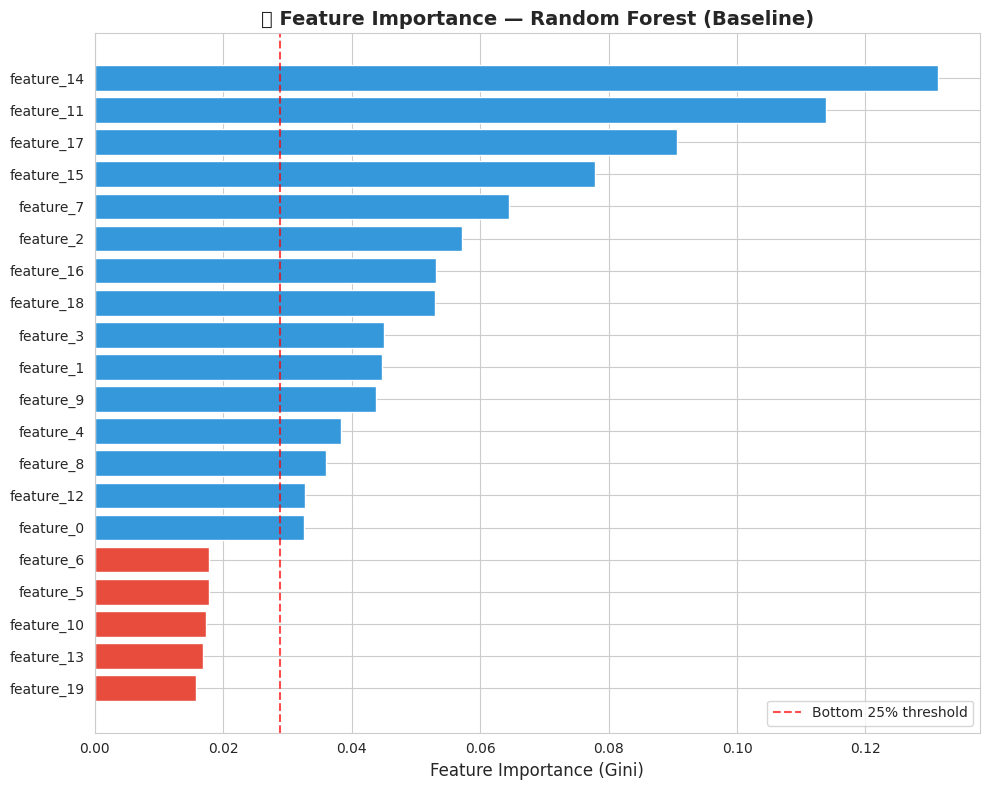


🔴 Red bars = lowest importance features (candidates for removal)
🔵 Blue bars = higher importance features (keep these)

Top 5 features: ['feature_7', 'feature_15', 'feature_17', 'feature_11', 'feature_14']
Bottom 5 features: ['feature_19', 'feature_13', 'feature_10', 'feature_5', 'feature_6']


In [8]:
# ── Feature Importance Bar Chart ───────────────────────────────
importances = rf_baseline.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if imp < np.percentile(importances, 25) else "#3498db" 
          for imp in importance_df["Importance"]]
ax.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("🎯 Feature Importance — Random Forest (Baseline)", fontsize=14, fontweight="bold")
ax.axvline(x=np.percentile(importances, 25), color="red", linestyle="--", alpha=0.7, label="Bottom 25% threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔴 Red bars = lowest importance features (candidates for removal)")
print("🔵 Blue bars = higher importance features (keep these)")
print(f"\nTop 5 features: {importance_df.tail(5)['Feature'].tolist()}")
print(f"Bottom 5 features: {importance_df.head(5)['Feature'].tolist()}")

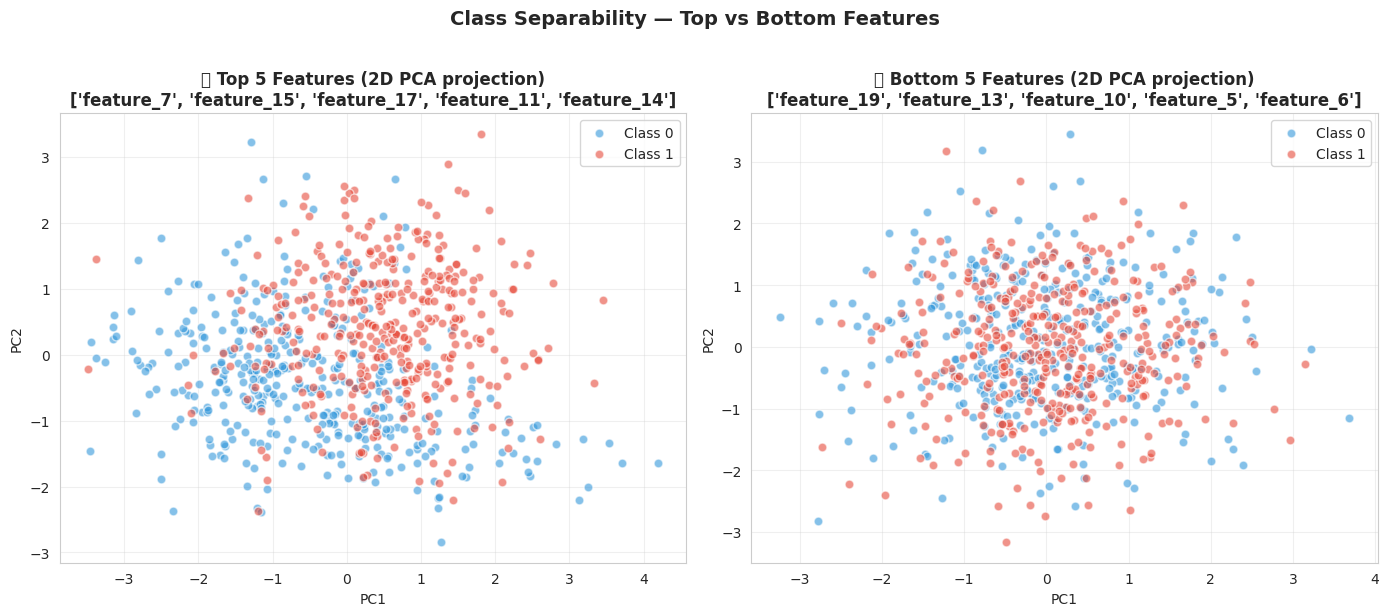

👉 If the top-5 plot shows clearer separation between blue/red than the
   bottom-5 plot, that's visual confirmation the model's importance
   ranking is meaningful — those features actually carry class signal.


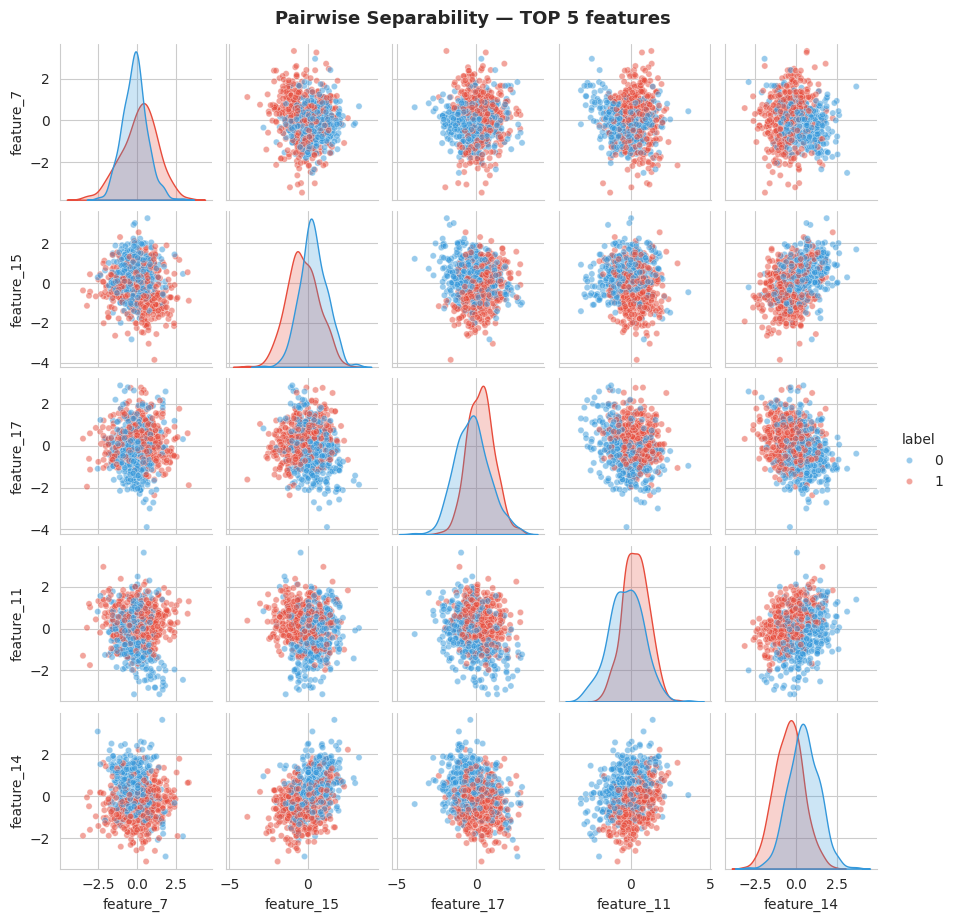

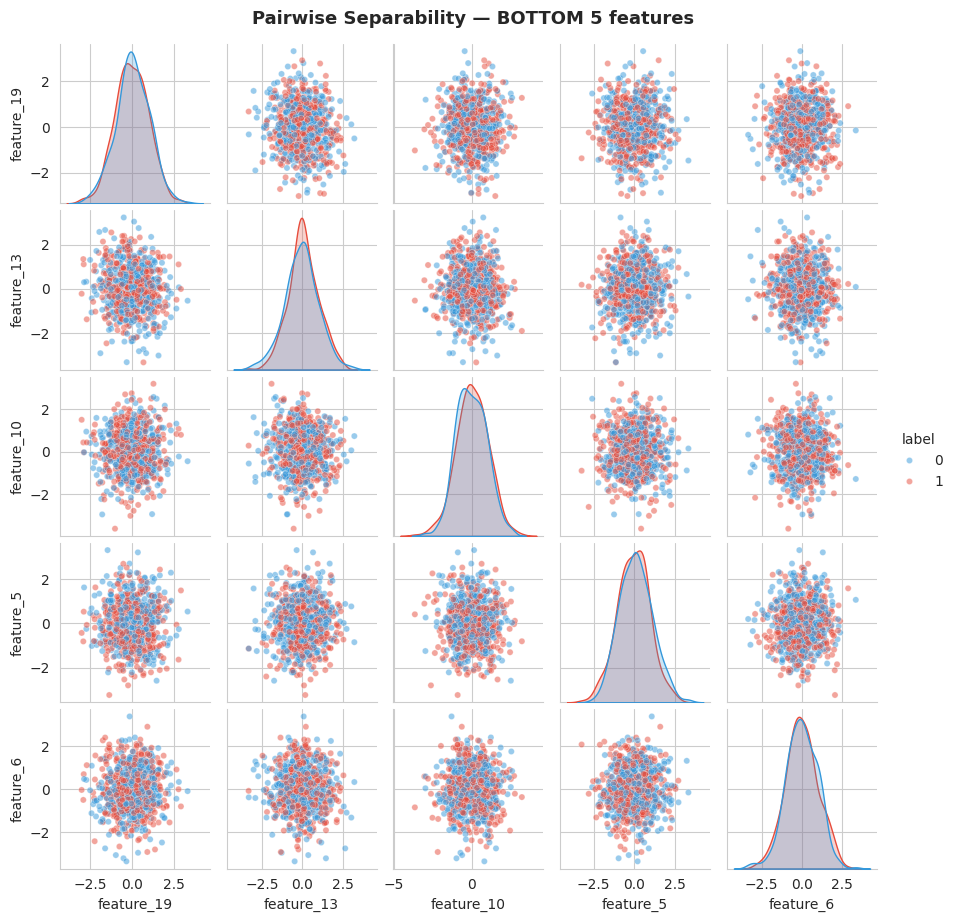


What to look for in the pairplots:
  • Diagonal KDEs: do the two class distributions overlap or separate?
  • Off-diagonal scatter: do blue/red points form distinct clusters?
  • Top-5 panels should look more 'separated' than bottom-5 panels.


In [9]:

# Get top 5 and bottom 5 feature names from importance ranking
top5_features    = importance_df.tail(5)["Feature"].tolist()
bottom5_features = importance_df.head(5)["Feature"].tolist()

# Convert scaled arrays back to DataFrames so we can select by column name
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

X_top5    = X_train_scaled_df[top5_features].values
X_bottom5 = X_train_scaled_df[bottom5_features].values

# Project each group down to 2D using PCA so we can plot separability
pca_top    = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_top5)
pca_bottom = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_bottom5)

# Colour map: class 1 vs class 0
class_colors = {0: "#3498db", 1: "#e74c3c"}
class_labels = {0: "Class 0", 1: "Class 1"}

# ── Plot: side-by-side 2D PCA scatter ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in np.unique(y_train):
    mask = (y_train == cls)
    axes[0].scatter(pca_top[mask, 0], pca_top[mask, 1],
                    c=class_colors[cls], label=class_labels[cls],
                    alpha=0.6, edgecolor="white", s=40)
    axes[1].scatter(pca_bottom[mask, 0], pca_bottom[mask, 1],
                    c=class_colors[cls], label=class_labels[cls],
                    alpha=0.6, edgecolor="white", s=40)

axes[0].set_title(f"🔵 Top 5 Features (2D PCA projection)\n{top5_features}",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title(f"🔴 Bottom 5 Features (2D PCA projection)\n{bottom5_features}",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Class Separability — Top vs Bottom Features",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("👉 If the top-5 plot shows clearer separation between blue/red than the")
print("   bottom-5 plot, that's visual confirmation the model's importance")
print("   ranking is meaningful — those features actually carry class signal.")

# ── Pairwise scatter matrix for finer-grained inspection ───────
def pairwise_separability(features, title, cmap_label=""):
    df_plot = X_train_scaled_df[features].copy()
    df_plot["label"] = y_train.values if hasattr(y_train, "values") else y_train

    fig = sns.pairplot(
        df_plot,
        hue="label",
        palette={0: "#3498db", 1: "#e74c3c"},
        diag_kind="kde",
        plot_kws={"alpha": 0.5, "s": 20, "edgecolor": "white"},
        height=1.8,
    )
    fig.fig.suptitle(f"{title}", y=1.02, fontsize=13, fontweight="bold")
    plt.show()

# NOTE: requires seaborn — import at top of notebook if not already: `import seaborn as sns`
pairwise_separability(top5_features,    "Pairwise Separability — TOP 5 features")
pairwise_separability(bottom5_features, "Pairwise Separability — BOTTOM 5 features")

print("\nWhat to look for in the pairplots:")
print("  • Diagonal KDEs: do the two class distributions overlap or separate?")
print("  • Off-diagonal scatter: do blue/red points form distinct clusters?")
print("  • Top-5 panels should look more 'separated' than bottom-5 panels.")


### 5b. Correlation Heatmap

Highly correlated features provide **redundant information**. If two features are nearly identical, the model doesn't gain much from having both — and it increases the risk of overfitting.


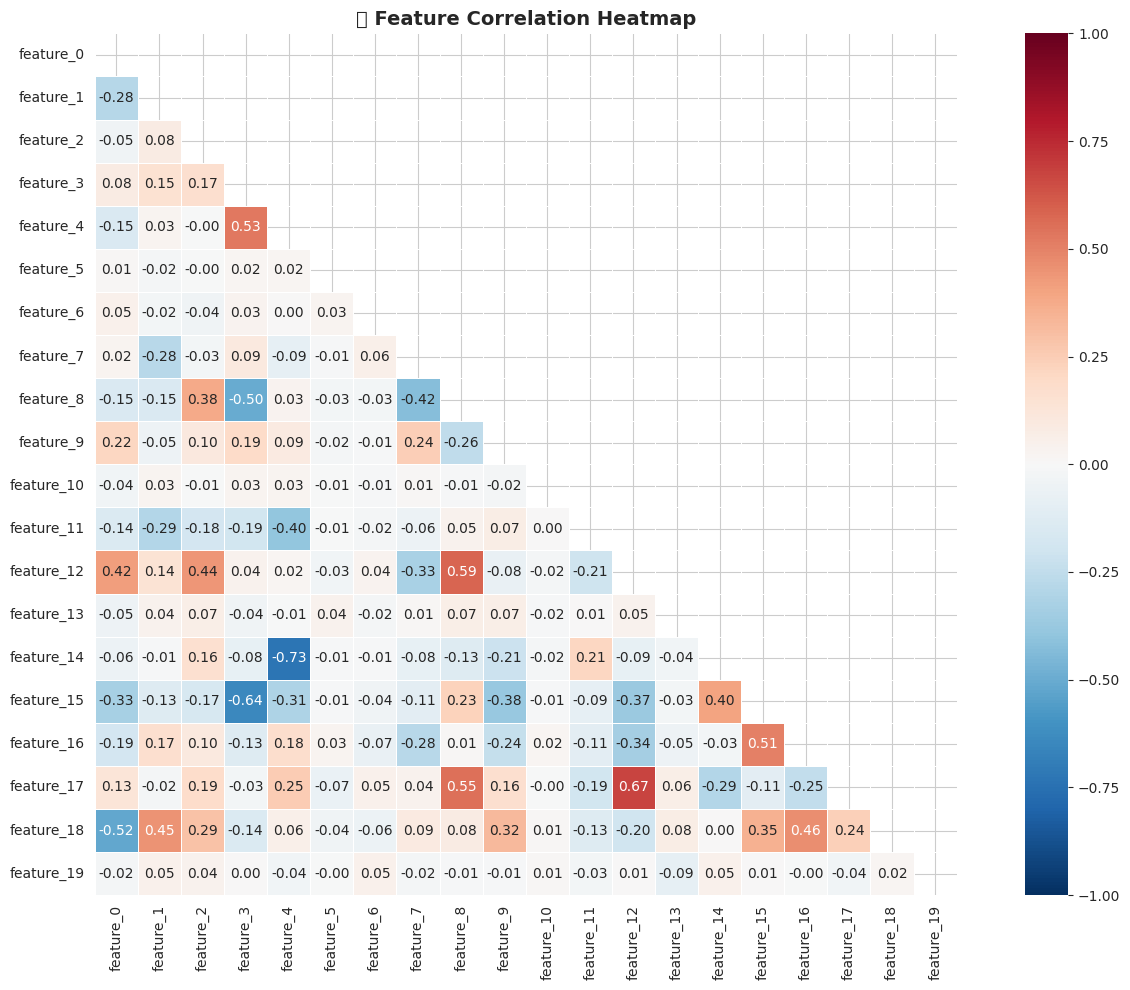


⚠️ Highly correlated feature pairs (|r| > 0.7):
   feature_4 ↔ feature_14: r = -0.734


In [10]:
# ── Correlation Heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
correlation_matrix = X_train_scaled.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("📊 Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], 
                 correlation_matrix.iloc[i, j])
            )

if high_corr_pairs:
    print("\n⚠️ Highly correlated feature pairs (|r| > 0.7):")
    for f1, f2, corr in high_corr_pairs:
        print(f"   {f1} ↔ {f2}: r = {corr:.3f}")
else:
    print("\n✅ No highly correlated feature pairs found (|r| > 0.7)")


### 5c. The Payoff — Retrain with Top Features Only

Now let's **drop the low-importance features** and retrain. Does performance stay the same or improve?


In [11]:
# ── Select Top Features & Retrain ──────────────────────────────
# Sort features by importance and select the top N
N_TOP_FEATURES = 10

top_features = importance_df.tail(N_TOP_FEATURES)["Feature"].tolist()
print(f"Selected top {N_TOP_FEATURES} features: {top_features}")
print(f"Dropped {20 - N_TOP_FEATURES} features\n")

# Retrain with selected features only
X_train_selected = X_train_scaled[top_features]
X_test_selected = X_test_scaled[top_features]

rf_selected = RandomForestClassifier(random_state=RANDOM_STATE)
rf_selected.fit(X_train_selected, y_train)

y_pred_selected = rf_selected.predict(X_test_selected)
y_proba_selected = rf_selected.predict_proba(X_test_selected)

selected_accuracy = accuracy_score(y_test, y_pred_selected)
selected_logloss = log_loss(y_test, y_proba_selected)

# ── Comparison ────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Log Loss", "Num Features"],
    "Baseline (All 20 Features)": [f"{baseline_accuracy:.4f}", f"{baseline_logloss:.4f}", "20"],
    "After Feature Selection (Top 10)": [f"{selected_accuracy:.4f}", f"{selected_logloss:.4f}", str(N_TOP_FEATURES)]
})

print("=" * 60)
print("COMPARISON — Before vs After Feature Selection")
print("=" * 60)
print(comparison.to_string(index=False))

acc_diff = selected_accuracy - baseline_accuracy
print(f"\nAccuracy change: {acc_diff:+.4f}")
if acc_diff >= 0:
    print("✅ Performance maintained or improved — with FEWER features!")
    print("   → Faster training, simpler model, less overfitting risk")
else:
    print("⚠️ Slight accuracy drop — but with half the features!")
    print("   → May still be worth it for speed and interpretability")


Selected top 10 features: ['feature_1', 'feature_3', 'feature_18', 'feature_16', 'feature_2', 'feature_7', 'feature_15', 'feature_17', 'feature_11', 'feature_14']
Dropped 10 features

COMPARISON — Before vs After Feature Selection
      Metric Baseline (All 20 Features) After Feature Selection (Top 10)
    Accuracy                     0.9100                           0.9100
    Log Loss                     0.2899                           0.2633
Num Features                         20                               10

Accuracy change: +0.0000
✅ Performance maintained or improved — with FEWER features!
   → Faster training, simpler model, less overfitting risk


### 💡 The "Aha" Moment

We **dropped half the features** and the model's performance was maintained (or even improved). This demonstrates:

- Not all features are useful — **noise hurts more than it helps**
- A simpler model with the right features can outperform a complex model with all features
- **In real-world scenarios** (e.g., from 1,000s of features), only the best ~20 may be needed

> 🎯 **Takeaway:** Feature selection is often the **highest-impact, lowest-effort** improvement you can make.

---


---

## ⚙️ Section 6 — Hyperparameter Optimisation

### Key Random Forest Hyperparameters

| Hyperparameter | What It Controls | Low Value | High Value |
|---|---|---|---|
| `n_estimators` | Number of trees in the forest | Faster but less accurate | Slower but more robust |
| `max_depth` | Maximum depth of each tree | Simpler trees (underfitting risk) | Complex trees (overfitting risk) |
| `min_samples_split` | Min samples to split a node | More splits (complex) | Fewer splits (simple) |
| `min_samples_leaf` | Min samples in a leaf node | Complex trees | Simpler trees |
| `max_features` | Features considered per split | Less randomness | More randomness |



| Parameter | Value | What it controls | Concretely, what this value means |
|---|---|---|---|
| **`n_estimators`** | `67` | Number of decision trees in the forest. Each tree casts one vote; the majority wins. | The forest builds **67 separate trees** on 67 different bootstrap samples. A new row gets classified by collecting **67 votes** and taking the majority. If 40 trees say "Class 1" and 27 say "Class 0", the prediction is **Class 1** with probability **40/67 ≈ 0.60**. |
| **`max_depth`** | `20` | How many consecutive yes/no questions a single tree can chain together from root to leaf. | A tree can ask up to **20 questions in a row** before being forced to make a prediction. With 20 binary splits, a single tree can carve the feature space into up to **2²⁰ ≈ 1 million** regions — plenty of capacity, but capped so it can't grow to 40–50 levels deep and memorise individual rows. |
| **`max_features`** | `'sqrt'` | How many features are considered as candidates at **each split** inside every tree. | If your dataset has, say, **30 features**, then at every single split the algorithm only looks at **√30 ≈ 5 randomly chosen features** and picks the best split among those 5. The other 25 are ignored for that split. This happens **fresh at every node**, so different splits in the same tree see different feature subsets. |
| **`min_samples_split`** | `8` | The smallest a node can be and still be eligible for splitting. | If a node contains **7 or fewer training samples**, the tree stops splitting it and turns it into a leaf — even if it's impure. A node with **8 or more samples** is allowed to split further. This stops the tree from carving off tiny "groups of 3" that are almost certainly noise. |
| **`min_samples_leaf`** | `1` | The smallest a leaf (final prediction node) is allowed to be. | A leaf can contain as few as **1 training sample**. So once a node has 8+ samples and decides to split, the resulting children can be as small as 1 sample each. Combined with `min_samples_split=8`, the rule is: *"don't bother splitting small groups, but if you do split, you can split them all the way down."* |
    
---


### 6b. Level 1 — Manual / Random Guessing ❌ (Slowest)

Just try different values by hand and see what happens. No structure, no guarantee.


In [12]:
# ── Level 1: Manual Hyperparameter Tuning ──────────────────────
manual_configs = [
    {"n_estimators": 50,  "max_depth": 5,  "min_samples_split": 2},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 5},
]

print("=" * 70)
print("LEVEL 1 — Manual Hyperparameter Tuning")
print("=" * 70)

start_manual = time.time()

manual_results = []
for i, config in enumerate(manual_configs, 1):
    rf_manual = RandomForestClassifier(random_state=RANDOM_STATE, **config)
    scores = cross_val_score(rf_manual, X_train_scaled, y_train, cv=5, scoring="accuracy")
    manual_results.append({
        "Config": i,
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "Mean CV Accuracy": f"{scores.mean():.4f} ± {scores.std():.4f}"
    })
    print(f"  Config {i}: {config} → Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

time_manual = time.time() - start_manual
print(f"\n⏱️ Time taken: {time_manual:.2f}s")
print("\n❌ Problem: Slow, unstructured, no guarantee of finding good values")

LEVEL 1 — Manual Hyperparameter Tuning
  Config 1: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2} → Accuracy: 0.8925 ± 0.0165
  Config 2: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5} → Accuracy: 0.9175 ± 0.0145

⏱️ Time taken: 2.27s

❌ Problem: Slow, unstructured, no guarantee of finding good values


### 6b. Level 2 — Grid Search CV ⚠️ (Good)

Define a grid of values for each hyperparameter and try **every combination** with cross-validation.

**Pros:** Exhaustive — guaranteed to find the best combination *within the grid*  
**Cons:** Scales exponentially — more hyperparameters × more values = explosion of combinations

### What 3-Fold Cross-Validation Looks Like

```
Training data split into 3 folds:
┌─────────┬─────────┬─────────┐
│ Fold 1  │ Fold 2  │ Fold 3  │
└─────────┴─────────┴─────────┘

Round 1:  [VALIDATE] [ TRAIN  ] [ TRAIN  ]  → accuracy_1
Round 2:  [ TRAIN  ] [VALIDATE] [ TRAIN  ]  → accuracy_2
Round 3:  [ TRAIN  ] [ TRAIN  ] [VALIDATE]  → accuracy_3

Mean CV accuracy = (accuracy_1 + accuracy_2 + accuracy_3) / 3
```

- Every row is used for **validation exactly once** and for **training twice**.
- The reported CV score is the **average across all 3 rounds**, which is more robust than a single train/validation split.

In [13]:
# ── Define the grid ────────────────────────────────────────────
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
}
n_combinations = np.prod([len(v) for v in param_grid.values()])
cv_folds = 3
total_fits = n_combinations * cv_folds

print("=" * 70)
print("LEVEL 2 — Grid Search CV")
print("=" * 70)
print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {n_combinations}")
print(f"With {cv_folds}-fold CV: {total_fits} model fits\n")
print("Searching... (this may take a moment)\n")

# ── Run Grid Search ────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_folds,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=False,
    verbose=0,
)

start = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"✅ Best parameters:   {grid_search.best_params_}")
print(f"✅ Best CV accuracy:  {grid_search.best_score_:.4f}")
print(f"⏱️  Time taken:        {elapsed:.2f}s\n")

# ── Build a per-fold results table (all 24 fits) ───────────────
results = pd.DataFrame(grid_search.cv_results_)

fold_cols = [f"split{i}_test_score" for i in range(cv_folds)]

detailed = results[["params"] + fold_cols + ["mean_test_score", "std_test_score"]].copy()
detailed = detailed.rename(columns={
    "split0_test_score": "Fold 1 acc",
    "split1_test_score": "Fold 2 acc",
    "split2_test_score": "Fold 3 acc",
    "mean_test_score":   "Mean CV acc",
    "std_test_score":    "Std",
})

# Expand the params dict into individual columns for readability
params_df = pd.json_normalize(detailed["params"])
detailed = pd.concat([params_df, detailed.drop(columns=["params"])], axis=1)
detailed = detailed.sort_values("Mean CV acc", ascending=False).reset_index(drop=True)

print("=" * 70)
print("ALL 24 FITS — accuracy per fold for each of the 8 combinations")
print("=" * 70)
print(detailed.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

LEVEL 2 — Grid Search CV
Parameter grid: {'n_estimators': [50, 100], 'max_depth': [5, 10], 'min_samples_split': [2, 5]}
Total combinations: 8
With 3-fold CV: 24 model fits

Searching... (this may take a moment)

✅ Best parameters:   {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV accuracy:  0.9213
⏱️  Time taken:        5.52s

ALL 24 FITS — accuracy per fold for each of the 8 combinations
 max_depth  min_samples_split  n_estimators  Fold 1 acc  Fold 2 acc  Fold 3 acc  Mean CV acc    Std
        10                  2           100      0.9213      0.8951      0.9474       0.9213 0.0213
        10                  5           100      0.9213      0.8839      0.9474       0.9175 0.0261
        10                  5            50      0.8951      0.9026      0.9474       0.9150 0.0231
        10                  2            50      0.9139      0.9026      0.9286       0.9150 0.0106
         5                  2            50      0.9026      0.8876      0.9398    

### 6b. Level 3 — Random Search CV ⚠️ (Better)

Instead of trying every combination, **sample randomly** from the search space.

Surprisingly effective — research has shown random search often outperforms grid search because it explores the space more efficiently, especially when some hyperparameters matter more than others.


In [14]:
# ── Level 3: Random Search CV ──────────────────────────────────
param_distributions = {
    "n_estimators": randint(50, 300),
    "max_depth": [5, 10, 20, None],
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None]
}

n_iter = 20
cv_folds = 3

print("=" * 70)
print("LEVEL 3 — Random Search CV")
print("=" * 70)
print(f"Search space: Broader distributions than Grid Search")
print(f"Number of random samples: {n_iter}")
print(f"With {cv_folds}-fold CV: {n_iter * cv_folds} model fits")
print("\nSearching...")

start_random = time.time()

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=n_iter,
    cv=cv_folds,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
random_search.fit(X_train_scaled, y_train)

time_random = time.time() - start_random

print(f"\n✅ Best parameters: {random_search.best_params_}")
print(f"✅ Best CV accuracy: {random_search.best_score_:.4f}")
print(f"⏱️ Time taken: {time_random:.2f}s\n")

# ── Show every random combination that was trialed ─────────────
results = pd.DataFrame(random_search.cv_results_)

fold_cols = [f"split{i}_test_score" for i in range(cv_folds)]

trialed = results[["params"] + fold_cols + ["mean_test_score", "std_test_score"]].copy()
trialed = trialed.rename(columns={
    "split0_test_score": "Fold 1 acc",
    "split1_test_score": "Fold 2 acc",
    "split2_test_score": "Fold 3 acc",
    "mean_test_score":   "Mean CV acc",
    "std_test_score":    "Std",
})

# Expand the params dict into individual columns for readability
params_df = pd.json_normalize(trialed["params"])
trialed = pd.concat([params_df, trialed.drop(columns=["params"])], axis=1)
trialed = trialed.sort_values("Mean CV acc", ascending=False).reset_index(drop=True)
trialed.index = trialed.index + 1  # rank starting at 1

print("=" * 70)
print(f"ALL {n_iter} RANDOM COMBINATIONS TRIALED (sorted best → worst)")
print("=" * 70)
print(trialed.to_string(float_format=lambda x: f"{x:.4f}"))

LEVEL 3 — Random Search CV
Search space: Broader distributions than Grid Search
Number of random samples: 20
With 3-fold CV: 60 model fits

Searching...

✅ Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 67}
✅ Best CV accuracy: 0.9188
⏱️ Time taken: 42.76s

ALL 20 RANDOM COMBINATIONS TRIALED (sorted best → worst)
    max_depth max_features  min_samples_leaf  min_samples_split  n_estimators  Fold 1 acc  Fold 2 acc  Fold 3 acc  Mean CV acc    Std
1     20.0000         sqrt                 1                  8            67      0.9213      0.8951      0.9398       0.9188 0.0183
2         NaN         log2                 2                  5            63      0.9139      0.8951      0.9436       0.9175 0.0200
3         NaN         sqrt                 4                  3           299      0.9176      0.8764      0.9474       0.9138 0.0291
4     10.0000         log2                 5                  3           2

### 6b. Level 4 — Optuna ✅ (Powerful — Bayesian Optimisation)

**What makes Optuna different?**

Grid Search and Random Search are **memoryless** — they don't learn from the trials they've already run. Optuna does. After every trial, it **updates its understanding** of which regions of the search space tend to produce good models, and uses that knowledge to choose smarter hyperparameters next time.

This is called **Bayesian Optimisation**, and Optuna's default implementation is called **TPE — Tree-structured Parzen Estimator**.

---

### 🧠 The Core Idea, in Plain English

Imagine you're tasting wines to find the best one in a huge cellar:

- **Grid Search** = taste *every* bottle on a predefined shelf. Exhaustive but slow.
- **Random Search** = grab bottles at random. Cheap, surprisingly effective, but still blind.
- **Optuna (Bayesian)** = after every sip, you **remember** which regions of the cellar produced good wines, and you **start exploring near those shelves**. Occasionally you wander to a new shelf to make sure you're not missing something better.

That balance is the heart of Optuna:

- 🔍 **Exploration** — try new, unexplored areas (so you don't miss a hidden winner).
- 🎯 **Exploitation** — focus on areas that have already shown promise (so you refine the best regions).

---

### ⚙️ How TPE Actually Works (Step by Step)

Here's what happens under the hood on each trial:

1. **Start with a few random trials** (typically the first 10) to gather some initial data. Optuna has nothing to learn from yet.
2. After enough trials, Optuna **splits past trials into two groups**:
   - 🟢 **"Good" trials** — the top ~25% by score.
   - 🔴 **"Bad" trials** — everyone else.
3. It builds **two probability distributions** over the hyperparameter space:
   - `l(x)` = "what hyperparameter values tended to appear in **good** trials?"
   - `g(x)` = "what hyperparameter values tended to appear in **bad** trials?"
4. For the next trial, Optuna picks values that **maximise the ratio `l(x) / g(x)`** — i.e. values that are **likely to be good** and **unlikely to be bad**.
5. Run the trial → get a new score → **update the two distributions** → repeat.

```
       Past trials so far
       ┌──────────────────────────┐
       │ Trial 1: n=50,  d=5  → 0.81 │
       │ Trial 2: n=200, d=20 → 0.92 │  ← Good
       │ Trial 3: n=80,  d=10 → 0.88 │
       │ Trial 4: n=300, d=3  → 0.74 │  ← Bad
       │ ...                          │
       └──────────────┬───────────────┘
                      ▼
       Split into Good (top 25%) vs Bad (rest)
                      ▼
       Build l(x) = distribution of values in good trials
             g(x) = distribution of values in bad trials
                      ▼
       Next trial: pick x that maximises l(x) / g(x)
                      ▼
       Run trial → record score → update l(x), g(x) → repeat
```

So unlike Grid/Random Search, **every new trial is informed by every previous trial**.

---

### ✂️ Pruning — Stop Wasting Time on Losers

Optuna can also **kill a trial mid-training** if it's clearly going to underperform. For example:

- After 1 of 3 CV folds, if the score is far below what other trials achieved at the same stage, Optuna **prunes** that trial and moves on.
- This means even a "50 trial" study often runs in the **time of 20–30 full trials**.

This is why Optuna can afford to run **far more trials than Grid Search** in the same wall-clock time.

---

### Key Optuna Concepts

| Concept | Description | Concrete example |
|---|---|---|
| **Study** | The overall optimisation task — the "experiment" you're running. | "Find the best Random Forest for our churn dataset." |
| **Trial** | A single evaluation of one hyperparameter combination. | Trial 7: `n_estimators=120, max_depth=15` → CV accuracy 0.89. |
| **Objective** | The function Optuna calls each trial. You define what to minimise (e.g. log loss) or maximise (e.g. accuracy). | `def objective(trial): ... return cv_accuracy` |
| **Sampler** | The algorithm that decides *which hyperparameters to try next*. Default = TPE. | `optuna.samplers.TPESampler()` |
| **Pruning** | Stops weak trials early so compute isn't wasted on hopeless configurations. | After fold 1, if accuracy < median of past trials at fold 1 → kill. |

---

### 📊 Why This Matters in Practice

| Search method | Uses past trials? | Can prune? | Typical trials needed |
|---|---|---|---|
| Grid Search | ❌ No | ❌ No | Hundreds–thousands |
| Random Search | ❌ No | ❌ No | 20–100 |
| **Optuna (TPE)** | ✅ Yes | ✅ Yes | **20–50** for similar or better results |

> 🔥 **Real-world context:** "In our production pipeline, we moved from Hyperopt to Optuna. With Hyperopt we ran ~5 trials per region. With Optuna's pruning and efficiency, we run 20 trials per region and it still finishes within an hour."

---

### 💡 The One-Line Takeaway

> **Optuna = Random Search that remembers what worked, plus the option to stop bad trials early.**

That's it. Every other detail (TPE, samplers, pruners) is just *how* it implements those two ideas efficiently.

In [15]:
# ── Level 4: Optuna Hyperparameter Optimisation ────────────────

def objective(trial):
    """Optuna objective function for Random Forest optimisation."""
    
    # Define the search space — Optuna suggests values intelligently
    n_estimators = trial.suggest_int("n_estimators", 50, 500, step=25)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    # Build the model with suggested hyperparameters
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # Evaluate with cross-validation
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring="accuracy")
    return scores.mean()

print("=" * 70)
print("LEVEL 4 — Optuna (Bayesian Optimisation)")
print("=" * 70)
print("Optimising... (25 trials with intelligent sampling)\n")

# Enable Optuna's default trial logging (matches your production pipeline)
optuna.logging.set_verbosity(optuna.logging.INFO)

start_optuna = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=25)

time_optuna = time.time() - start_optuna

# Set back to WARNING to keep the rest of the notebook clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"\n✅ Best parameters: {study.best_params}")
print(f"✅ Best CV accuracy: {study.best_value:.4f}")
print(f"⏱️ Time taken: {time_optuna:.2f}s")
print(f"📊 Total trials: {len(study.trials)}")

[I 2026-06-19 07:48:14,198] A new study created in memory with name: no-name-9a0db44a-ac38-4bbd-8deb-3e3b23dc3816


LEVEL 4 — Optuna (Bayesian Optimisation)
Optimising... (25 trials with intelligent sampling)



[I 2026-06-19 07:48:17,379] Trial 0 finished with value: 0.91875 and parameters: {'n_estimators': 225, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.91875.
[I 2026-06-19 07:48:24,244] Trial 1 finished with value: 0.9225000000000001 and parameters: {'n_estimators': 450, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-19 07:48:29,459] Trial 2 finished with value: 0.9049999999999999 and parameters: {'n_estimators': 125, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-19 07:48:30,898] Trial 3 finished with value: 0.91875 and parameters: {'n_estimators': 100, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9225000000000001.
[I 2026-06-19 07:48:40,884] Tr


✅ Best parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2'}
✅ Best CV accuracy: 0.9263
⏱️ Time taken: 158.97s
📊 Total trials: 25


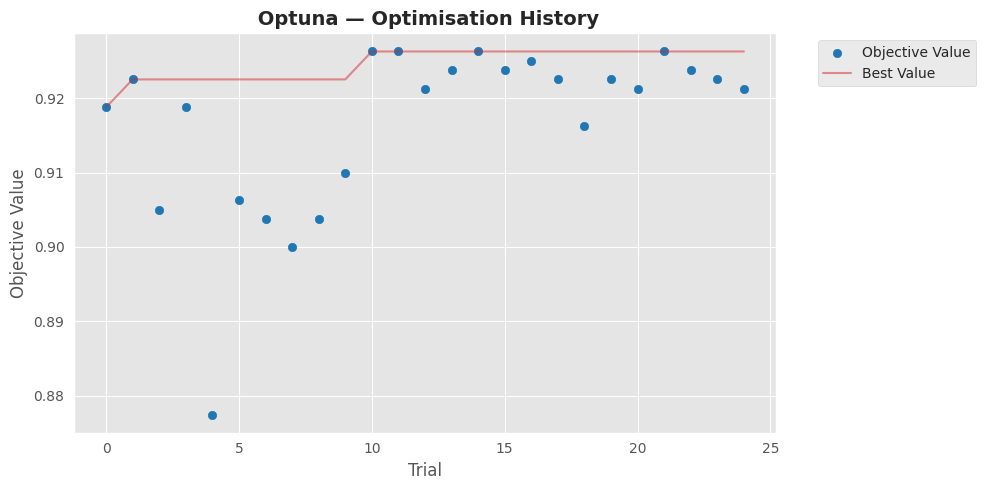

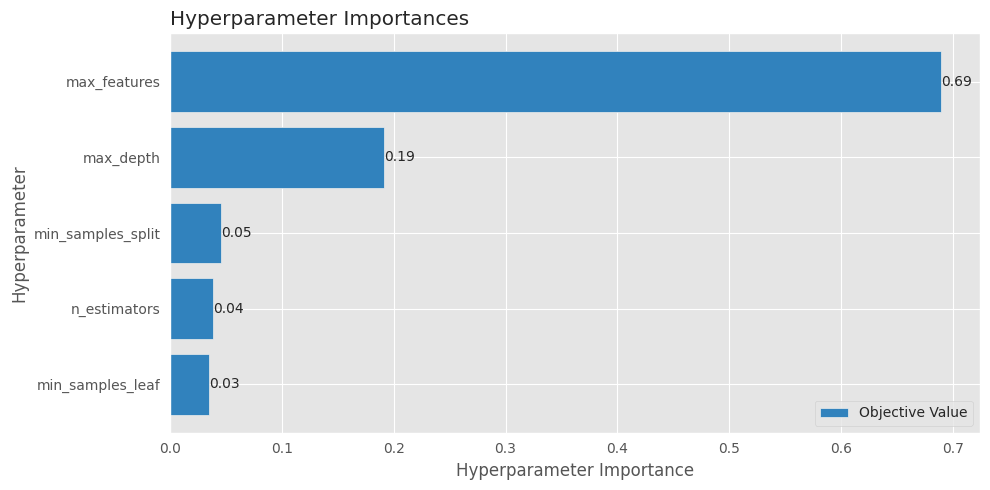


💡 These plots show which hyperparameters had the biggest impact
   on model performance — focus your tuning efforts there!


In [16]:
# ── Optuna Visualisations ──────────────────────────────────────

# 1. Optimisation History — how the best value improves over trials
ax1 = plot_optimization_history(study)
ax1.set_title(" Optuna — Optimisation History", fontsize=14, fontweight="bold")
ax1.figure.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

# 2. Hyperparameter Importances — which hyperparameters mattered most
ax2 = plot_param_importances(study)
ax2.figure.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

print("\n💡 These plots show which hyperparameters had the biggest impact")
print("   on model performance — focus your tuning efforts there!")

### 📊 Method Comparison — All Four Approaches


In [17]:
# ── Build Comparison Table ──────────────────────────────────────
# Get the best scores from each method
best_manual_score = max([float(r["Mean CV Accuracy"].split(" ±")[0]) for r in manual_results])

method_comparison = pd.DataFrame({
    "Method": [
        "❌ Manual Guessing",
        "⚠️ Grid Search CV",
        "⚠️ Random Search CV",
        "✅ Optuna (Bayesian)"
    ],
    "Best CV Accuracy": [
        f"{best_manual_score:.4f}",
        f"{grid_search.best_score_:.4f}",
        f"{random_search.best_score_:.4f}",
        f"{study.best_value:.4f}"
    ],
    "Time (seconds)": [
        f"{time_manual:.2f}s",
        f"{elapsed:.2f}s",
        f"{time_random:.2f}s",
        f"{time_optuna:.2f}s"
    ],
    "Intelligence": [
        "None",
        "Exhaustive but unintelligent",
        "Stochastic sampling",
        "Bayesian (learns from results)"
    ],
    "Scalability": [
        "❌ Poor",
        "❌ Exponential",
        "✅ Good",
        "✅ Excellent"
    ]
})

print("=" * 90)
print("COMPARISON — Hyperparameter Optimisation Methods")
print("=" * 90)
print(method_comparison.to_string(index=False))

COMPARISON — Hyperparameter Optimisation Methods
             Method Best CV Accuracy Time (seconds)                   Intelligence   Scalability
  ❌ Manual Guessing           0.9175          2.27s                           None        ❌ Poor
  ⚠️ Grid Search CV           0.9213          5.52s   Exhaustive but unintelligent ❌ Exponential
⚠️ Random Search CV           0.9188         42.76s            Stochastic sampling        ✅ Good
✅ Optuna (Bayesian)           0.9263        158.97s Bayesian (learns from results)   ✅ Excellent


---

### Summary of the Progression

| Level | Method | Intelligence | Speed | Scalability |
|---|---|---|---|---|
| 1 | Manual Guessing | ❌ None | ❌ Slowest | ❌ Poor |
| 2 | Grid Search CV | ❌ Exhaustive but unintelligent | ⚠️ Exponential growth | ❌ Poor |
| 3 | Random Search CV | ⚠️ Stochastic | ✅ Good | ✅ Good |
| **4** | **Optuna (Bayesian)** | **✅ Learns from results** | **✅ Fast (pruning)** | **✅ Excellent** |

---


---

## 🤖 Section 7 — Auto Model Selection (Enrichment / Advanced)

### 7a. The Idea

So far we've been optimising **one model** (Random Forest). But what if a completely different model architecture would perform better?

**Auto model selection** = systematically try **multiple model types**, each with their own optimised hyperparameters, and **pick the winner**.

---

### 7b. The Candidate Models

| Model | Key Strength | How It Works |
|---|---|---|
| **XGBoost** | Competition winner, very fast | Gradient boosting — builds trees sequentially, each correcting the previous one's errors |
| **Histogram-based Gradient Boosting (HGBT)** | Scales to large datasets | sklearn's implementation — bins features into histograms for faster training |
| **CatBoost** | Great out-of-the-box performance | Handles categorical features natively, uses ordered boosting to reduce overfitting |

**Key point:** Each model has its *own* set of hyperparameters. Manually tuning each one would be extremely time-consuming.

---

### 7c. PyCaret — Automated Model Comparison

**PyCaret** is an open-source, low-code ML library that wraps scikit-learn, XGBoost, LightGBM, CatBoost, and Optuna behind a **unified API**.

With `compare_models()`, PyCaret trains and evaluates **15-25+ algorithms** with cross-validation in a single function call — then returns a leaderboard ranked by your chosen metric.

> 📝 **Note:** PyCaret requires `pip install pycaret`. If it's not installed, this section shows the code pattern and expected output.

---


In [18]:
# # Recreate the full DataFrame for PyCaret
# df_pycaret = df.copy()

# print("=" * 70)
# print("AUTO MODEL SELECTION — PyCaret")
# print("=" * 70)

# # Step 1: Setup the experiment
# # PyCaret handles preprocessing, train/test split, and encoding automatically
# exp = ClassificationExperiment()
# exp.setup(
#     data=df_pycaret,
#     target="target",
#     session_id=RANDOM_STATE,
#     normalize=True,
#     fold=5,
#     verbose=False
# )
# print("\n✅ Step 1: Experiment setup complete")

# # Step 2: Compare multiple models automatically
# # This trains and evaluates 15+ algorithms with cross-validation
# print("\n🔄 Step 2: Comparing models... (this may take a few minutes)")
# best_models = exp.compare_models(n_select=3, sort="Accuracy")

# print("\n✅ Step 2: Model comparison complete")
# print("\nTop 3 models selected by PyCaret:")
# for i, model in enumerate(best_models, 1):
#     print(f"  {i}. {type(model).__name__}")

# # Step 3: Tune the best model's hyperparameters
# print("\n🔄 Step 3: Tuning best model hyperparameters...")
# tuned_model = exp.tune_model(best_models[0], n_iter=20, optimize="Accuracy")
# print("✅ Step 3: Tuning complete")

# # Step 4: Finalise — retrain on the full dataset
# print("\n🔄 Step 4: Finalising model (retrain on full dataset)...")
# final_model = exp.finalize_model(tuned_model)
# print("✅ Step 4: Final model ready for deployment!")

# print("\n" + "=" * 70)
# print("🎉 In ~5 lines of code, PyCaret just:")
# print("   • Compared 15+ algorithms with cross-validation")
# print("   • Selected the top 3 performers")
# print("   • Tuned the best model's hyperparameters")
# print("   • Retrained on the full dataset")
# print("   • Gave us a production-ready pipeline")
# print("=" * 70)

### 💡 Why PyCaret?

| Without PyCaret | With PyCaret |
|---|---|
| Manually import each model library | One unified API |
| Write separate train/evaluate loops for each model | `compare_models()` — one line |
| Manually implement cross-validation per model | Built-in CV for all models |
| Manually tune each model's hyperparameters | `tune_model()` — one line |
| Hours of boilerplate code | ~5 lines total |

> 🎯 **When to use PyCaret:** Rapid prototyping, model selection, benchmarking. When you need to quickly find which model family works best for your data.

> ⚙️ **When to use Optuna directly:** Production optimisation, fine-grained control, custom objective functions, integration with existing pipelines.

---


---

## 🏁 Section 8 — Recap & Key Takeaways

### The Three Levers of Model Performance

| # | Lever | What It Does | Key Tool |
|---|---|---|---|
| 1 | 🎯 **Feature Selection** | Give the model *better* inputs — drop noise, keep signal | `.feature_importances_`, correlation analysis |
| 2 | ⚙️ **Hyperparameter Optimisation** | Tune *how* the model learns — find the best configuration | Manual → Grid Search → Random Search → **Optuna** |
| 3 | 🤖 **Auto Model Selection** | Try *different* model architectures — don't assume your first choice is best | **PyCaret**, manual comparison |

### The Hierarchy

```
1️⃣  Get your FEATURES right first
     ↓
2️⃣  Then TUNE the model's hyperparameters
     ↓
3️⃣  Then EXPERIMENT with different model architectures
```

### Our Journey Today

```
Baseline Model (default RF, all 20 features)
     ↓
Feature Selection (top 10 features → simpler, equally good)
     ↓
Hyperparameter Optimisation (Optuna → better performance)
     ↓
Auto Model Selection (PyCaret → best architecture found automatically)
```

### 📣 Call to Action

This Jupyter Notebook is yours — go experiment!
- Change the synthetic data parameters
- Try different numbers of features
- Increase the Optuna trial count
- Add your own models to the comparison
- **Break things and learn from it!**

---

*Thank you! Questions?* 🙋

---

## 📚 Further Reading & Resources

### Core Concepts
- **Scikit-learn User Guide** — [scikit-learn.org/stable/user_guide.html](https://scikit-learn.org/stable/user_guide.html) — Comprehensive reference for all models, preprocessing, and evaluation metrics used in this notebook

### Feature Selection
- **Scikit-learn Feature Selection** — [scikit-learn.org/stable/modules/feature_selection.html](https://scikit-learn.org/stable/modules/feature_selection.html) — Univariate selection, recursive feature elimination, and more

### Hyperparameter Optimisation
- **Optuna Documentation** — [optuna.readthedocs.io](https://optuna.readthedocs.io/) — Full guide on studies, samplers (TPE), pruning, and visualisations
- **Optuna GitHub Examples** — [github.com/optuna/optuna-examples](https://github.com/optuna/optuna-examples) — Ready-to-run examples for sklearn, XGBoost, LightGBM, CatBoost, and more
- **Random Search vs Grid Search (Bergstra & Bengio, 2012)** — [jmlr.org/papers/v13/bergstra12a.html](https://jmlr.org/papers/v13/bergstra12a.html) — The foundational paper showing why random search often beats grid search

### Auto Model Selection
- **PyCaret Documentation** — [pycaret.gitbook.io](https://pycaret.gitbook.io/) — Guides for classification, regression, clustering, and time series
- **PyCaret GitHub** — [github.com/pycaret/pycaret](https://github.com/pycaret/pycaret) — Source code, tutorials, and community examples

### Gradient Boosting Models
- **XGBoost Documentation** — [xgboost.readthedocs.io](https://xgboost.readthedocs.io/)
- **CatBoost Documentation** — [catboost.ai/docs](https://catboost.ai/docs/)
- **Histogram-based Gradient Boosting (sklearn)** — [scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting](https://scikit-learn.org/stable/modules/ensemble.html#histogram-based-gradient-boosting)

---